# Бинарная классификация текстов (IMDB) с наивным Байесом

Решаем задачу по определению положительной/негативной рецензии на данных кинорецензий IMDB.

## План
1. Установка пакетов.
2. Импорты и фиксирование случайности для генератора СЧ с целью сохранения воспроизводимости результатов.
3. Загрузка IMDB с HF и перевод в `pandas.DataFrame`.
4. Быстрый осмотр и баланс классов.
5. Разбиение на `train/test` (80/20) со стратификацией.
6. Базовый конвейер для **MultinomialNB** и кросс-валидация (CV).
7. Влияние `alpha` для **MultinomialNB** (с фиксированной токенизацией).
8. Сравнение токенизаций: простой `.split()` и `CountVectorizer` с (1,1), (1,2), (2,2).
9. Сравнение моделей: **MultinomialNB**, **ComplementNB**, **BernoulliNB** (с небольшим набором `alpha`).
10. Финальная оценка лучшей конфигурации на **тесте**: отчёт, матрица ошибок, метрики, ROC-AUC.


## Шаг 1. Установка пакетов


In [ ]:
%pip -q install datasets       # пакет с готовыми датасетами (HuggingFace): удобная загрузка IMDB и др.
%pip -q install scikit-learn   # основная библиотека для классического ML: сплиты, пайплайны, модели, метрики
%pip -q install matplotlib     # библиотека для визуализации: графики, матрица ошибок, ROC-кривая
%pip -q install pandas         # табличное представление данных (DataFrame)

## Шаг 2. Импорты и фиксирование случайности

In [ ]:
from datasets import load_dataset                           # загрузка датасета IMDB
import pandas as pd                                                 # DataFrame-формат (таблицы)
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold  # сплит и CV
from sklearn.pipeline import Pipeline                               # конвейер: препроцессинг → модель
from sklearn.feature_extraction.text import CountVectorizer         # мешок СЧЁТЧИКОВ токенов, поддерживает n-граммы
from sklearn.naive_bayes import MultinomialNB, ComplementNB, BernoulliNB  # три варианта NB
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_curve, roc_auc_score  # метрики и графики

import numpy as np                                                  # векторные операции
import random                                                       # базовый ГСЧ Python
import os                                                           # переменные окружения
import matplotlib.pyplot as plt                                     # построение графиков в ноутбуке

RANDOM_STATE = 42                                                   # единое "зерно" случайности
random.seed(RANDOM_STATE)                                           # фиксируем ГСЧ Python
np.random.seed(RANDOM_STATE)                                        # фиксируем ГСЧ NumPy
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)                    # стабилизируем хеширование строк/объектов

## Шаг 3. Загрузка IMDB и перевод в DataFrame

In [ ]:
ds = load_dataset("imdb")                                # скачиваем и загружаем IMDB словарь со сплитами
ds = ds["train"]                                                    # используем официальный 'train' (25k размеченных отзывов)
df = ds.to_pandas()                                                 # переводим в pandas.DataFrame
df.head(3)                                                          # первые 3 строки — быстрый визуальный контроль

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0


## Шаг 4. Быстрый осмотр и баланс классов

In [ ]:
df.tail(3)                                              # последние 3 строки — проверяем, что всё ок до конца таблицы
df['label'].value_counts().sort_index()                             # количество объектов в каждом классе (0=neg, 1=pos)
df['label'].value_counts(normalize=True).round(3).sort_index()      # доли классов (в сумме ≈1.0)

,proportion
label,
0,0.5
1,0.5


## Шаг 5. Разбиваем на train/test (80/20) со стратификацией (необязательно)

In [ ]:
X = df['text'].tolist()                                  # все тексты как список строк
y = df['label'].tolist()                                             # все метки (0/1) как список

X_train, X_test, y_train, y_test = train_test_split(                # один сплит: обучающая и тестовая части
    X, y,                                                           # полный набор текстов и меток
    test_size=0.20,                                                 # 20% оставляем на финальную оценку
    stratify=y,                                                     # сохраняем баланс классов в обеих частях
    random_state=RANDOM_STATE                                       # фиксируем сид для воспроизводимости
)
len(X_train), len(X_test)                                           # контроль размеров (≈ 80% и 20%)

(20000, 5000)

## Шаг 6. Базовый конвейер: CountVectorizer(1-2-граммы) + MultinomialNB(alpha=1.0) -> CV-оценка

In [ ]:
pipe_base = Pipeline([                                   # собираем базовый конвейер
    ('vect', CountVectorizer(min_df=5, ngram_range=(1,2))),          # униграммы+биграммы; отбрасываем редкие слова (min_df=5) для скорости
    ('clf', MultinomialNB(alpha=1.0)),                                # MultinomialNB со сглаживанием по умолчанию
])

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)  # 3-фолдовая CV для скорости
cv_scores = cross_val_score(                                         # оцениваем модель на обучающей части
    pipe_base, X_train, y_train,                                     # обучаем и валидируем только внутри train
    cv=cv, scoring='f1'                                              # метрика F1 (подходит для сбалансированных классов)
)
print(f'CV F1 mean ± std: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}') # печатаем среднее и разброс

CV F1 mean ± std: 0.867 ± 0.005


## Шаг 7. Влияние `alpha` для MultinomialNB (фиксируем токенизацию: уни+би-граммы)

In [ ]:
alphas = [0.1, 0.25, 0.05, 0.75]          # набор значений сглаживания
results_alpha = {}                        # сюда сложим результаты

for a in alphas:                          # перебираем alpha
    pipe = Pipeline([
        ('vect', CountVectorizer(min_df=5, ngram_range=(1, 2))),  # униграммы+биграммы, min_df=5
        ('clf', MultinomialNB(alpha=a)),  # текущее значение alpha
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1')  # F1 в кросс-валидации
    results_alpha[a] = [scores.mean(), scores.std()]  # сохраняем среднее и std

# Печатаем сводку по alpha
for a in results_alpha.keys():
    print(f'alpha={a}: CV F1={results_alpha[a][0]:.4f} ± {results_alpha[a][1]:.4f}')

# Поиск лучшего alpha
best_alpha, best_f1 = -1, -1
for alpha, (mean_f1, std_f1) in results_alpha.items():
    if mean_f1 > best_f1:
        best_f1 = mean_f1
        best_alpha = alpha

print('Лучший alpha по CV:', best_alpha)

alpha=0.1: CV F1=0.8705 ± 0.0046
alpha=0.25: CV F1=0.8691 ± 0.0043
alpha=0.05: CV F1=0.8714 ± 0.0053
alpha=0.75: CV F1=0.8680 ± 0.0041
Лучший alpha по CV: 0.05


## Шаг 8. Сравнение токенизаций (для выбранного `alpha`)

In [ ]:
tokenizations = {                                       # варианты токенизации
    'split_unigram': CountVectorizer(tokenizer=str.split,           # ИСПОЛЬЗУЕМ простой split по пробелам
                                     preprocessor=None,             # без доп. предобработки
                                     lowercase=True,                # приводим к нижнему регистру
                                     token_pattern=None,            # отключаем regex-токенизацию
                                     min_df=5),                     # отбрасываем редкие токены для скорости
    'cv_unigram':   CountVectorizer(ngram_range=(1,1), min_df=5),   # только униграммы
    'cv_uni_bi':    CountVectorizer(ngram_range=(1,2), min_df=5),   # униграммы+биграммы
    'cv_bigram':    CountVectorizer(ngram_range=(2,2), min_df=10)   # только биграммы, min_df=10 для компактности
}

results_tok = []                                                    # сюда будем складывать результаты

for name, vect in tokenizations.items():                            # перебор по вариантам токенизации
    pipe = Pipeline([                                               # конвейер: токенизация -> NB
        ('vect', vect),                                             # текущий векторизатор
        ('clf', MultinomialNB(alpha=best_alpha)),                   # лучший alpha из шага 7
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1')  # CV-оценка на train
    results_tok.append((name, scores.mean(), scores.std()))         # сохраняем среднее и std

for name, m, s in results_tok:                                      # печатаем сводку
    print(f'{name:12s}: CV F1={m:.4f} ± {s:.4f}')                   # строка отчёта

# Поиск лучшей токенизации
best_tok, best_f1 = None, -1.0                                      # инициализируем «лучший» вариант
for name, mean_f1, std_f1 in results_tok:                           # перебор результатов
    if mean_f1 > best_f1:                                           # обновляем, если F1 стал лучше
        best_f1 = mean_f1                                           # сохраняем лучший F1
        best_tok = name                                             # и имя лучшего токенизатора

print('Лучший токенизатор по CV:', best_tok)                        # отчёт о победителе

# --- Кладём ЛУЧШУЮ MultinomialNB (пайплайн) в словарь
best_vect = tokenizations[best_tok]                                 # берём лучший векторизатор
mnb_best = Pipeline([('vect', best_vect), ('clf', MultinomialNB(alpha=best_alpha))])  # собираем пайплайн
mnb_best.fit(X_train, y_train)                                      # обучаем на всей тренировочной части
models = {}

models['MultinomialNB'] = mnb_best                                  # сохраняем обученный пайплайн в словарь

split_unigram: CV F1=0.8365 ± 0.0061
cv_unigram  : CV F1=0.8375 ± 0.0047
cv_uni_bi   : CV F1=0.8714 ± 0.0053
cv_bigram   : CV F1=0.8678 ± 0.0029
Лучший токенизатор по CV: cv_uni_bi


## Шаг 9. Сравнение MultinomialNB с  ComplementNB и BernoulliNB

In [ ]:
# --- Фиксированный токенайзер (лучший из прошлого шага) + простой перебор МОДЕЛЕЙ и alpha ---
vect = tokenizations[best_tok]                         # берём заранее выбранный лучший токенайзер

alphas = [0.1, 0.25, 0.05, 0.75]                       # набор значений сглаживания для перебора
models_to_try = ['ComplementNB', 'BernoulliNB']        # какие модели проверяем (по именам)

results = []                                           # сюда складываем строки с результатами (для печати)
best_by_model = {}                                     # сюда запишем лучший alpha и лучший F1 по каждой модели

for model_name in models_to_try:                       # идём по моделям
    best_alpha_for_model = -1                        # сюда положим лучший alpha для текущей модели
    best_f1_for_model = -1                          # сюда лучший средний F1 по CV для этой модели

    for a in alphas:                                   # перебор значений alpha
        if model_name == 'BernoulliNB':                # создаём классификатор с нужными параметрами
            clf = BernoulliNB(alpha=a, binarize=0.0)   # для BernoulliNB бинаризация: count>0 → 1
        else:
            clf = ComplementNB(alpha=a)                # для ComplementNB только alpha

        pipe = Pipeline([                              # конвейер из двух шагов
            ('vect', vect),                            # шаг 1: векторизация текста
            ('clf',  clf),                             # шаг 2: классификатор
        ])

        scores = cross_val_score(                      # кросс-валидация ТОЛЬКО на train
            pipe, X_train, y_train,
            cv=cv, scoring='f1'                        # метрика F1
        )
        mean_f1 = scores.mean()                        # средний F1 по фолдам
        std_f1  = scores.std()                         # стандартное отклонение F1 по фолдам

        results.append((model_name, a, mean_f1, std_f1))          # сохраняем строку с результатом
        if mean_f1 > best_f1_for_model:                           # если стало лучше — обновляем «лучший»
            best_f1_for_model = mean_f1                           # лучший F1 для модели
            best_alpha_for_model = a                              # лучший alpha для модели

    best_by_model[model_name] = (best_alpha_for_model, best_f1_for_model)   # фиксируем лучшую пару

# Печать таблички результатов
print('Модель         alpha   CV F1 (mean ± std)')
for model_name, a, m, s in results:                  # просто пройдёмся по собранным строкам
    print(f'{model_name:13s} {a:>5}   {m:.3f} ± {s:.3f}')

# Печать лучших alpha по каждой модели
print('\nЛучшие настройки (фикс. токенайзер:', best_tok, '):')
for model_name, (a, m) in best_by_model.items():
    print(f'- {model_name:13s}: alpha={a}, CV F1={m:.3f}')

for model_name, (a, m) in best_by_model.items():      # для каждой модели создаём финальный пайплайн
    if model_name == 'BernoulliNB':
        clf_best = BernoulliNB(alpha=a, binarize=0.0) # BernoulliNB с лучшим alpha
    else:
        clf_best = ComplementNB(alpha=a)              # ComplementNB с лучшим alpha

    pipe_best = Pipeline([
        ('vect', vect),                                # тот же фиксированный токенайзер
        ('clf',  clf_best),                            # лучший классификатор
    ])
    pipe_best.fit(X_train, y_train)                    # обучение на всей тренировочной части

    models[model_name] = pipe_best                     # кладём обученный пайплайн в словарь
    print(f"Сохранено: models['{model_name}'] (alpha={a}, tokenizer={best_tok}).")


Модель         alpha   CV F1 (mean ± std)
ComplementNB    0.1   0.871 ± 0.005
ComplementNB   0.25   0.869 ± 0.004
ComplementNB   0.05   0.871 ± 0.005
ComplementNB   0.75   0.868 ± 0.004
BernoulliNB     0.1   0.875 ± 0.006
BernoulliNB    0.25   0.874 ± 0.006
BernoulliNB    0.05   0.876 ± 0.006
BernoulliNB    0.75   0.873 ± 0.006

Лучшие настройки (фикс. токенайзер: cv_uni_bi ):
- ComplementNB : alpha=0.05, CV F1=0.871
- BernoulliNB  : alpha=0.05, CV F1=0.876
Сохранено: models['ComplementNB'] (alpha=0.05, tokenizer=cv_uni_bi).
Сохранено: models['BernoulliNB'] (alpha=0.05, tokenizer=cv_uni_bi).


## Шаг 10. Финальная оценка на тесте: отчёт, матрица ошибок и ROC-AUC

MultinomialNB | F1_macro=0.868 | acc=0.868 | AUC=0.935
ComplementNB  | F1_macro=0.868 | acc=0.868 | AUC=0.935
BernoulliNB   | F1_macro=0.873 | acc=0.873 | AUC=0.941

Лучшая модель по F1_macro: BernoulliNB
              precision    recall  f1-score   support

           0      0.866     0.882     0.874      2500
           1      0.880     0.863     0.872      2500

    accuracy                          0.873      5000
   macro avg      0.873     0.873     0.873      5000
weighted avg      0.873     0.873     0.873      5000



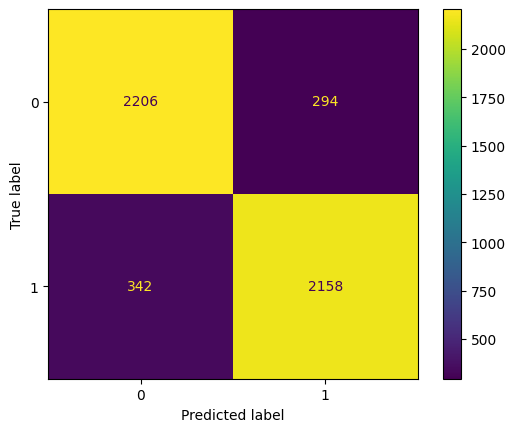

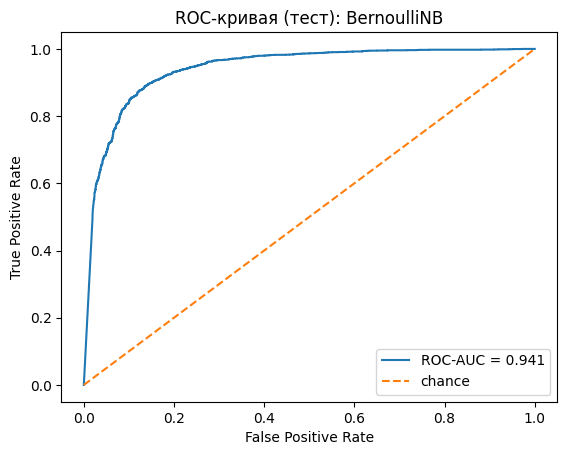

In [ ]:
# --- Финальная оценка: выбираем лучшую модель и строим метрики/графики ---

# Пробегаем по всем моделям в словаре и считаем метрики на тесте
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score, roc_curve  # метрики
summary = []                                                      # сюда соберём (name, F1_macro, acc, AUC)

for name, pipe in models.items():                                 # для каждой сохранённой модели
    y_pred  = pipe.predict(X_test)                                 # предсказанные метки
    y_proba = pipe.predict_proba(X_test)[:, 1]                     # вероятность положительного класса
    f1m = f1_score(y_test, y_pred, average='macro')                # F1_macro
    acc = accuracy_score(y_test, y_pred)                           # accuracy
    auc = roc_auc_score(y_test, y_proba)                           # ROC-AUC
    summary.append((name, f1m, acc, auc))                          # добавляем в сводку
    print(f"{name:13s} | F1_macro={f1m:.3f} | acc={acc:.3f} | AUC={auc:.3f}")  # короткий отчёт

# Выбираем победителя по F1_macro
best_name, _, _, _ = max(summary, key=lambda t: t[1])              # модель с максимальным F1_macro
best_pipe = models[best_name]                                      # сам пайплайн победителя
print(f"\nЛучшая модель по F1_macro: {best_name}")

# Полный отчёт по лучшей модели
y_pred = best_pipe.predict(X_test)                                  # предсказания лучшей модели
print(classification_report(y_test, y_pred, digits=3))              # подробные precision/recall/F1

# Матрица ошибок
_ = ConfusionMatrixDisplay.from_estimator(best_pipe, X_test, y_test)

# ROC-кривая и ROC-AUC
y_proba = best_pipe.predict_proba(X_test)[:, 1]                     # вероятности класса 1
auc = roc_auc_score(y_test, y_proba)                                # ROC-AUC числом
fpr, tpr, _ = roc_curve(y_test, y_proba)                            # точки ROC

plt.figure()                                                        # отдельный график
plt.plot(fpr, tpr, label=f'ROC-AUC = {auc:.3f}')                    # ROC-кривая
plt.plot([0, 1], [0, 1], '--', label='chance')                      # диагональ «случайного»
plt.xlabel('False Positive Rate')                                   # подпись оси X
plt.ylabel('True Positive Rate')                                    # подпись оси Y
plt.title(f'ROC-кривая (тест): {best_name}')                        # заголовок
plt.legend()                                                        # легенда
plt.show()                                                          # показать график


- **Лучший результат на тесте дал BernoulliNB**  
  - `F1_macro = 0.873`, `accuracy = 0.873`, `ROC-AUC = 0.941`.  
  - Для **MultinomialNB** и **ComplementNB** получили практически одинаковые результаты

- **Почему BernoulliNB чуть лучше?**  
  BernoulliNB использует **бинарные признаки** (наличие/отсутствие токена), что на отзывах IMDB может работать не хуже или чуть лучше счётчиков: важен сам факт упоминания характерных слов/фраз, а не их частота.

- **Матрица ошибок** (на 5000 примеров, классы сбалансированы по 2500):
  - Ложно-положительных: 294  
  - Ложно-отрицательных: 342  

- **ROC-АUC ≈ 0.94** говорит, что модель хорошо ранжирует положительные отзывы выше отрицательных


# Классификация с наивным Байесом: датасет "Weather Play"

Это "игрушечный" учебный датасет.

**Задача**: предсказать, будет ли играть в гольф человек (`Play = Yes/No`) в зависимости от погоды и влажности на улице.

Мы упростим исходные данные до **двух бинарных признаков**:
- `Outlook = Sunny` → 1, иначе 0
- `Humidity = High` → 1, иначе 0

Целевая переменная:
- `Play = Yes` → 1
- `Play = No` → 0

Всего **5000 наблюдений** посредством случайной генерации.

In [ ]:
import pandas as pd
import numpy as np

# Фиксируем случайность
np.random.seed(42)

# Определяем все возможные погодные условия
conditions = [
    ('Sunny', 'High'),
    ('Sunny', 'Low'),
    ('Rainy', 'High'),
    ('Rainy', 'Low')
]

# Вероятности для каждого условия (должны суммироваться в 1)
weather_probs = [0.3, 0.2, 0.3, 0.2]  # P(Sunny+High), P(Sunny+Low), ...

# Вероятности Play=Yes для каждого условия
play_probs = [0.2, 0.95, 0.3, 0.8]  # соответствуют условиям

# Генерируем 5000 примеров
n_samples = 5000
outlooks = []
humidities = []
plays = []

for _ in range(n_samples):
    # Выбираем ИНДЕКС условия с заданными вероятностями
    idx = np.random.choice(len(conditions), p=weather_probs)
    outlook, humidity = conditions[idx]

    # Решаем, будет ли игра
    p_yes = play_probs[idx]
    play = np.random.choice(['Yes', 'No'], p=[p_yes, 1 - p_yes])

    outlooks.append(outlook)
    humidities.append(humidity)
    plays.append(play)

# Создаём DataFrame
df_large = pd.DataFrame({
    'Outlook': outlooks,
    'Humidity': humidities,
    'Play': plays
})

print("Сгенерированный датасет (5000 строк):")
print(df_large.head(10))

print("\nРаспределение классов:")
print(df_large['Play'].value_counts(normalize=True).round(3))

print("\nКоличество по условиям:")
print(df_large.groupby(['Outlook', 'Humidity']).size())

Сгенерированный датасет (5000 строк):
  Outlook Humidity Play
0   Sunny      Low   No
1   Rainy     High   No
2   Sunny     High  Yes
3   Sunny     High   No
4   Rainy     High   No
5   Sunny     High   No
6   Rainy      Low  Yes
7   Sunny     High  Yes
8   Sunny      Low  Yes
9   Sunny      Low  Yes

Распределение классов:
Play
Yes    0.502
No     0.498
Name: proportion, dtype: float64

Количество по условиям:
Outlook  Humidity
Rainy    High        1493
         Low          958
Sunny    High        1547
         Low         1002
dtype: int64


## Преобразуем в бинарные признаки

Для упрощения сделаем:

- `sunny` = 1, если солнечно, иначе 0  
- `high_humidity` = 1,  иначе 0  
- `play` = 1, если идем играть и 0 иначе

In [ ]:
# Бинаризуем
df_bin_large = pd.DataFrame()
df_bin_large['sunny'] = (df_large['Outlook'] == 'Sunny').astype(int)      # 1 = Sunny, 0 = Rainy
df_bin_large['high_humidity'] = (df_large['Humidity'] == 'High').astype(int)  # 1 = High, 0 = Low
df_bin_large['play'] = (df_large['Play'] == 'Yes').astype(int)            # 1 = Yes, 0 = No

print("\nБинарный датасет (первые 5 строк):")
print(df_bin_large.head())

print("\nФорма данных:", df_bin_large.shape)


Бинарный датасет (первые 5 строк):
   sunny  high_humidity  play
0      1              0     0
1      0              1     0
2      1              1     1
3      1              1     0
4      0              1     0

Форма данных: (5000, 3)


## Разделение на признаки и целевую переменную, обучение классификатора


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import classification_report

# Разделяем на train/test (80/20)
X = df_bin_large[['sunny', 'high_humidity']]
y = df_bin_large['play']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Обучаем модель
model = CategoricalNB()
model.fit(X_train, y_train)

# Предсказания
y_pred = model.predict(X_test)

print("Модель обучена на", len(X_train), "примерах.")
print("Точность на тесте:", (y_pred == y_test).mean().round(4))

# Отчёт по классификации
print("\nОтчёт по классификации:")
print(classification_report(y_test, y_pred, target_names=['No', 'Yes']))

Модель обучена на 3750 примерах.
Точность на тесте: 0.7928

Отчёт по классификации:
              precision    recall  f1-score   support

          No       0.74      0.91      0.81       623
         Yes       0.88      0.68      0.77       627

    accuracy                           0.79      1250
   macro avg       0.81      0.79      0.79      1250
weighted avg       0.81      0.79      0.79      1250



## Предсказания для всех 4 возможных комбинаций

Поскольку у нас 2 бинарных признака, существует всего **4 возможных входа**:

| sunny | humidity | Ожидаемое решение (интуитивно) |
|-------|----------------|-------------------------------|
| 0     | 0              | ?                             |
| 0     | 1              | ?                             |
| 1     | 0              | ?                             |
| 1     | 1              | ?                             |

Давайте посмотрим, что скажет модель!

In [ ]:
import numpy as np

# Все возможные входы
combinations = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
labels = ['Rainy+Low', 'Rainy+High', 'Sunny+Low', 'Sunny+High']

probas = model.predict_proba(combinations)
preds = model.predict(combinations)

print("Предсказания модели на всех комбинациях:")
print("Условия        | P(No)  | P(Yes) | Предсказание")
print("-" * 48)
for label, prob, pred in zip(labels, probas, preds):
    p_no, p_yes = prob
    decision = "Yes" if pred == 1 else "No"
    print(f"{label:14} | {p_no:.3f}  | {p_yes:.3f}  | {decision}")

Предсказания модели на всех комбинациях:
Условия        | P(No)  | P(Yes) | Предсказание
------------------------------------------------
Rainy+Low      | 0.116  | 0.884  | Yes
Rainy+High     | 0.738  | 0.262  | No
Sunny+Low      | 0.122  | 0.878  | Yes
Sunny+High     | 0.749  | 0.251  | No


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but CategoricalNB was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but CategoricalNB was fitted with feature names
  warnings.warn(


## Решение задач по теор. веру на Python

## Задание 1
В ящике 5 синих и 3 красных шара. Извлекаются **два шара подряд без возвращения**. Найдите вероятность того, что:
1. оба шара синие,
2. хотя бы один из них красный.

*Подсказка: можно воспользоваться идеей условной вероятности или перевести задачу в правило произведения, как это было в примере на 9-й лекции.*

Запишите краткое решение и вычислите ответ (если есть желание - можете использовать Python в помощь для расчётов).

In [ ]:
from fractions import Fraction
import random

# Аналитически (через правило произведения)
p_both_blue = Fraction(5, 8) * Fraction(4, 7)           # P(оба синие) = (5/8)*(4/7)
p_at_least_one_red = 1 - p_both_blue                     # P(хотя бы один красный) = 1 - P(оба синие)

print("Аналитически:")
print("P(оба синие) =", p_both_blue, "=", float(p_both_blue))
print("P(хотя бы один красный) =", Fraction(p_at_least_one_red).limit_denominator(), "=", float(p_at_least_one_red))

def trial():
  urn = ["B"]*5 + ["R"]*3
  draw = random.sample(urn, 2)
  return draw

both_blue = 0
at_least_red = 0
N = 200_0000
for i in range(N):
  d = trial()
  if d.count("B") == 2:
    both_blue +=1
  if "R" in d:
    at_least_red +=1

print("Оба синие: ", both_blue/N)
print("Хотя бы один красный: ", at_least_red/N)


Аналитически:
P(оба синие) = 5/14 = 0.35714285714285715
P(хотя бы один красный) = 9/14 = 0.6428571428571429
Оба синие:  0.3577685
Хотя бы один красный:  0.6422315


## Задание 2
У вас есть спам-фильтр. Известно, что:

* 20% всех писем — это спам.
* Вероятность того, что в письме встречается слово «скидка», если это спам, — 60%.
* Вероятность того, что в письме встречается слово «скидка», если это не спам, — 10%.

Какова вероятность того, что письмо — спам, если в нём встречается слово «скидка»?

In [ ]:
from fractions import Fraction
import random

# Заданные вероятности
P_S = Fraction(1, 5)             # P(Spam) = 0.2
P_D_given_S = Fraction(3, 5)     # P("скидка"|Spam) = 0.6
P_D_given_notS = Fraction(1, 10) # P("скидка"|NotSpam) = 0.1

# Байес: P(Spam|"скидка") = P("скидка"|Spam) * P(Spam) / P("скидка")
P_D = P_D_given_S * P_S + P_D_given_notS * (1 - P_S)   # полная вероятность слова "скидка"
P_S_given_D = (P_D_given_S * P_S) / P_D                 # искомая апостериорная вероятность

print("Аналитически:")
print("P(\"скидка\") =", P_D, "=", float(P_D))
print("P(Spam | \"скидка\") =", P_S_given_D, "=", float(P_S_given_D))




Аналитически:
P("скидка") = 1/5 = 0.2
P(Spam | "скидка") = 3/5 = 0.6


## MC Тест

In [ ]:
# Небольшая проверка Монте‑Карло
N = 200_000
num_with_D = 0
num_spam_and_D = 0

for _ in range(N):
    is_spam = random.random() < float(P_S)                 # с вероятностью 0.2 — спам
    if is_spam:
        has_D = random.random() < float(P_D_given_S)       # слово "скидка" при спаме
    else:
        has_D = random.random() < float(P_D_given_notS)    # слово "скидка" при не спаме

    if has_D:
        num_with_D += 1
        if is_spam:
            num_spam_and_D += 1

mc_estimate = num_spam_and_D / num_with_D
print("\nМонте‑Карло (N = {:,}): P(Spam | \"скидка\") ≈ {:.3f}".format(N, mc_estimate))


Монте‑Карло (N = 200,000): P(Spam | "скидка") ≈ 0.596


## Задание 3

Среди определенной группы людей вероятность некоторой болезни 0,02. Тест, позволяющий выявить болезнь, несовершенен. На больном он дает позитивный результат в 98 случаях из 100, и, кроме того, он дает позитивный результат в 4 случаях из 100 на здоровом. Найдите вероятность того, что человек, на котором тест дал положительный результат, действительно болен.

In [ ]:
from fractions import Fraction
import random

# Данные задачи
p_disease = Fraction(2, 100)       # распространённость болезни P(D) = 0.02
sens = Fraction(98, 100)           # чувствительность P(+|D) = 0.98
fpr = Fraction(4, 100)             # ложноположительная P(+|~D) = 0.04

# Полная вероятность положительного теста
p_pos = sens * p_disease + fpr * (1 - p_disease)

# Байес: P(D|+) = P(+|D)P(D) / P(+)
p_d_given_pos = (sens * p_disease) / p_pos

print("Ответ:")
print("P(+)", "=", p_pos, "=", float(p_pos))
print("P(D|+)", "=", p_d_given_pos, "=", float(p_d_given_pos))



Ответ:
P(+) = 147/2500 = 0.0588
P(D|+) = 1/3 = 0.3333333333333333


## MC Тест

In [ ]:
# Небольшая проверка Монте‑Карло
N = 1000_000
pos = 0
true_pos = 0
for _ in range(N):
    sick = random.random() < float(p_disease)   # болен?
    if sick:
        test_pos = random.random() < float(sens)
    else:
        test_pos = random.random() < float(fpr)
    if test_pos:
        pos += 1
        if sick:
            true_pos += 1

mc = true_pos / pos
print(f"\nМонте‑Карло (N={N:,}): P(D|+) ≈ {mc:.5f}")



Монте‑Карло (N=1,000,000): P(D|+) ≈ 0.33575


## Задание 4

На склад поступило 3 партии изделий: первая – 1500 штук, вторая – 2500 штук, третья – 3000 штук. Средний процент нестандартных изделий в первой партии 10%, во второй – 8%, в третьей – 5%. Наудачу взятое со склада изделие оказалось нестандартным. Найти вероятность того, что оно:
* из первой партии;
* из второй партии
* из третьей партии.

In [ ]:
from fractions import Fraction

# Дано
N1, N2, N3 = 1500, 2500, 3000            # размеры партий
p_def_1, p_def_2, p_def_3 = Fraction(10,100), Fraction(8,100), Fraction(5,100)  # доли брака

total = N1 + N2 + N3
P1, P2, P3 = Fraction(N1, total), Fraction(N2, total), Fraction(N3, total)      # априорные вероятности партии

# Полная вероятность обнаружить брак
p_def = P1*p_def_1 + P2*p_def_2 + P3*p_def_3

# Байес: постериоры
post1 = P1*p_def_1 / p_def
post2 = P2*p_def_2 / p_def
post3 = P3*p_def_3 / p_def

print("P(брак) =", p_def, "=", float(p_def))
print("P(партия 1 | брак) =", post1, "=", float(post1))
print("P(партия 2 | брак) =", post2, "=", float(post2))
print("P(партия 3 | брак) =", post3, "=", float(post3))

print("\nПроверка: сумма постериоров =", float(post1 + post2 + post3))


P(брак) = 1/14 = 0.07142857142857142
P(партия 1 | брак) = 3/10 = 0.3
P(партия 2 | брак) = 2/5 = 0.4
P(партия 3 | брак) = 3/10 = 0.3

Проверка: сумма постериоров = 1.0


## Обход графов тремя алгоритмами

Цель: рассмотреит работу трёх классических алгоритмов в python реализации

## Алгоритм BFS

In [ ]:
import heapq  # Для приоритетной очереди
from collections import deque

In [ ]:
# Поиск в ширину

def bfs(graph, start_vertex):
    """
    Реализация поиска в ширину (Breadth-First Search).

    Аргументы:
    graph -- граф, представленный в виде словаря: {вершина: список соседей}
    start_vertex -- стартовая вершина для обхода

    Возвращает:
    levels -- словарь, где каждой вершине сопоставлен её уровень (расстояние в ребрах от стартовой)
    parents -- словарь, где каждой вершине сопоставлен её родитель в дереве обхода
    """
    visited = set()  # Множество посещённых вершин
    queue = deque([start_vertex])  # Очередь вершин на обработку, инициализирована стартовой вершиной
    levels = {start_vertex: 0}  # Уровень стартовой вершины — 0
    parents = {start_vertex: None}  # У стартовой вершины нет родителя

    while queue:
        vertex = queue.popleft()  # Извлекаем вершину из начала очереди
        visited.add(vertex)  # Помечаем как посещённую

        # Обходим всех соседей текущей вершины
        for neighbor in graph[vertex]:
            if neighbor not in visited:
                visited.add(neighbor)  # Помечаем соседа как посещённого
                queue.append(neighbor)  # Добавляем его в очередь для дальнейшего обхода
                levels[neighbor] = levels[vertex] + 1  # Уровень соседа на 1 больше уровня текущей вершины
                parents[neighbor] = vertex  # Устанавливаем текущую вершину как родителя для соседа

    return levels, parents

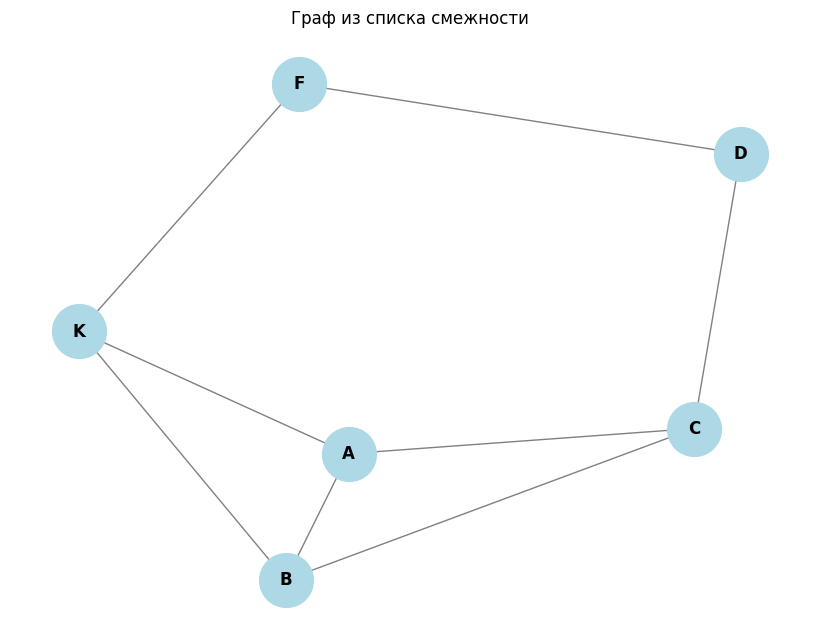

{'A': 0, 'C': 1, 'B': 1, 'K': 1, 'D': 2, 'F': 2}
{'A': None, 'C': 'A', 'B': 'A', 'K': 'A', 'D': 'C', 'F': 'K'}


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

adj_list = {
    'A': ['C', 'B', 'K'],   # A связана с C, B, K
    'C': ['A', 'B', 'D'],   # C связана с A, B, D
    'B': ['A', 'C', 'K'],   # B связана с A, C, K
    'K': ['A', 'B', 'F'],   # K связана с A, B, F
    'F': ['K', 'D'],        # F связана с K, D
    'D': ['C', 'F']         # D связана с C, F
}

# Создаём граф
G = nx.Graph()

# Добавляем рёбра из adj_list
for node, neighbors in adj_list.items():
    for neighbor in neighbors:
        G.add_edge(node, neighbor)

# Рисуем граф
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42)  # Чтобы граф каждый раз был одинаковым
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=1500, edge_color='gray', font_size=12, font_weight='bold')
plt.title("Граф из списка смежности")
plt.show()

levels, parents = bfs(adj_list, 'A')
print(levels)
print(parents)

## Поиск в глубину

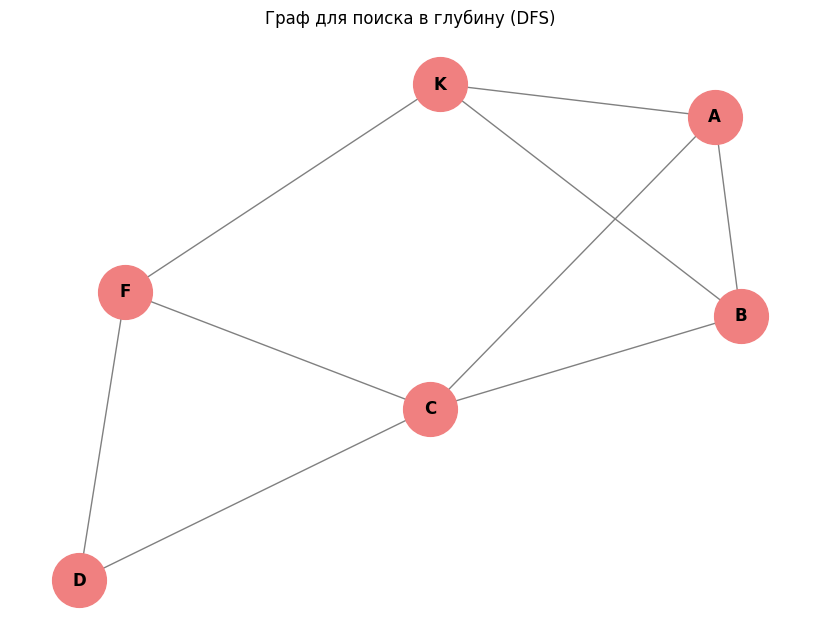

Итоговый путь: ['A', 'B', 'C', 'D', 'F', 'K']
Родители: {'A': None, 'B': 'A', 'C': 'B', 'D': 'C', 'F': 'D', 'K': 'F'}


In [ ]:
# Определяем граф
adj_list = {
    'A': ['B', 'C', 'K'],
    'B': ['A', 'C', 'K'],
    'C': ['A', 'B', 'D', 'F'],
    'D': ['C', 'F'],
    'F': ['K', 'D'],
    'K': ['A', 'B', 'F']
}

# Визуализация графа
plt.figure(figsize=(8, 6))
G = nx.Graph()
for node, neighbors in adj_list.items():
    for neighbor in neighbors:
        G.add_edge(node, neighbor)

pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color='lightcoral', node_size=1500,
        edge_color='gray', font_size=12, font_weight='bold')
plt.title("Граф для поиска в глубину (DFS)")
plt.show()

# Реализация DFS (включена прямо в ячейку для автономности)
def dfs(visited, graph, node, path, parents):
    """
    Рекурсивная реализация поиска в глубину (Depth-First Search).
    """
    if node not in visited:
        visited.add(node)
        path.append(node)
        for neighbor in graph[node]:
            if neighbor not in visited:
                parents[neighbor] = node
                dfs(visited, graph, neighbor, path, parents)

# Запуск DFS
visited = set()
parents = {'A': None}
path = []
dfs(visited, adj_list, 'A', path, parents)

# Вывод результатов
print("Итоговый путь:", path)
print("Родители:", parents)



## Дейкстра


In [ ]:
def dijkstra(graph, start_vertex):
    """
    Реализация алгоритма Дейкстры для взвешенного графа.

    Аргументы:
    graph -- словарь словарей: {вершина: {сосед: вес ребра}}
    start_vertex -- начальная вершина

    Возвращает:
    distances -- словарь кратчайших расстояний от start_vertex до всех остальных
    parents -- словарь родителей, позволяющий восстановить путь
    """
    # Инициализация расстояний: бесконечность, кроме стартовой вершины
    distances = {vertex: float('inf') for vertex in graph}
    distances[start_vertex] = 0

    # Родители для восстановления пути
    parents = {start_vertex: None}

    # Приоритетная очередь: (текущее расстояние, вершина)
    priority_queue = [(0, start_vertex)]

    while priority_queue:
        current_distance, current_vertex = heapq.heappop(priority_queue)

        # Если текущая вершина уже обойдена на более короткое расстояние, пропускаем
        if current_distance > distances[current_vertex]:
            continue

        # Проверяем всех соседей текущей вершины
        for neighbor, weight in graph[current_vertex].items():
            distance = current_distance + weight  # Обновлённое расстояние до соседа

            # Если найден более короткий путь до соседа — обновляем
            if distance < distances[neighbor]:
                distances[neighbor] = distance
                parents[neighbor] = current_vertex
                heapq.heappush(priority_queue, (distance, neighbor))  # Добавляем в очередь

    return distances, parents

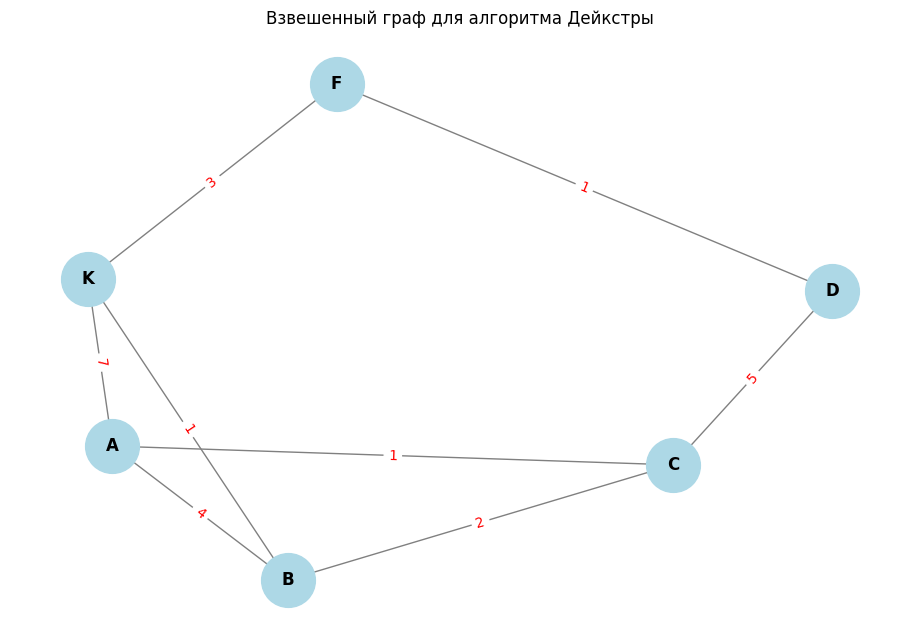

Кратчайшие расстояния: {'A': 0, 'C': 1, 'B': 3, 'K': 4, 'F': 7, 'D': 6}
Родители для восстановления путей: {'A': None, 'C': 'A', 'B': 'C', 'K': 'B', 'D': 'C', 'F': 'K'}


In [ ]:
# Определение взвешенного графа
weighted_graph = {
    'A': {'C': 1, 'B': 4, 'K': 7},
    'C': {'A': 1, 'B': 2, 'D': 5},
    'B': {'A': 4, 'C': 2, 'K': 1},
    'K': {'A': 7, 'B': 1, 'F': 3},
    'F': {'K': 3, 'D': 1},
    'D': {'C': 5, 'F': 1}
}

# Визуализация взвешенного графа
plt.figure(figsize=(9, 6))
G = nx.Graph()

# Добавляем рёбра с весами
for node, neighbors in weighted_graph.items():
    for neighbor, weight in neighbors.items():
        G.add_edge(node, neighbor, weight=weight)

pos = nx.spring_layout(G, seed=42)
edge_labels = nx.get_edge_attributes(G, 'weight')

nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=1500,
        edge_color='gray', font_size=12, font_weight='bold')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')
plt.title("Взвешенный граф для алгоритма Дейкстры")
plt.show()

# Запуск алгоритма
distances, parents = dijkstra(weighted_graph, 'A')

# Вывод результатов
print("Кратчайшие расстояния:", distances)
print("Родители для восстановления путей:", parents)

